## Libraries

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import math as math
from mpl_toolkits import mplot3d
# %matplotlib notebook

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score,recall_score,precision_score, accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV,GridSearchCV

In [3]:
import joblib

In [4]:
import mlflow
import mlflow.sklearn
from mlflow.models.signature import infer_signature


In [5]:
mlflow.set_tracking_uri("file:///D:/ITI/Courses/Technical/25-Machine-Learning-in-Production/Final_Project/research/mlruns")
mlflow.set_experiment("Hand Gesture Recognition Models")

<Experiment: artifact_location='file:///D:/ITI/Courses/Technical/25-Machine-Learning-in-Production/Final_Project/research/mlruns/171295864105552880', creation_time=1748788252151, experiment_id='171295864105552880', last_update_time=1748788252151, lifecycle_stage='active', name='Hand Gesture Recognition Models', tags={}>

## Functions

In [8]:
def set_axes_equal(ax):
    '''Make axes of 3D plot have equal scales so that hands appear realistic.'''
    limits = np.array([ax.get_xlim3d(), ax.get_ylim3d(), ax.get_zlim3d()])
    center = np.mean(limits, axis=1)
    max_range = np.max(np.abs(limits[:, 1] - limits[:, 0])) / 2

    for axis, c in zip([ax.set_xlim3d, ax.set_ylim3d, ax.set_zlim3d], center):
        axis([c - max_range, c + max_range])


In [9]:
def plot_samples(samples,graph_height=30):
    
    connections = [(0, 1), (1, 2), (2, 3), (3, 4),
                    (0, 5), (5, 6), (6, 7), (7, 8),
                    (5, 9), (9, 10), (10, 11), (11, 12), 
                    (9, 13), (13, 14), (14, 15), (15, 16), (13,17),
                    (0, 17), (17, 18), (18, 19), (19, 20)]   

    fig = plt.figure(figsize=(12,graph_height))  # Reduced height
    plot_rows = int(samples.shape[0] / 3)
    for i in range(samples.shape[0]):
        ax = fig.add_subplot(plot_rows, 3, i + 1, projection='3d')
        ax.view_init(elev=-90, azim=-90)
        sample = samples.iloc[i, :-1].values.reshape(-1, 3)
        label = samples.iloc[i, -1]
        ax.scatter(sample[:, 0], sample[:, 1], sample[:, 2], c='r', label='Landmarks')

        for (i, j) in connections:
            ax.plot([sample[i, 0], sample[j, 0]], 
                    [sample[i, 1], sample[j, 1]], 
                    [sample[i, 2], sample[j, 2]], 'k-')

        plt.title(label)
        # ax.set_box_aspect([1,1,1])
        set_axes_equal(ax)
        ax.set_xlabel("X")  
        ax.set_ylabel("Y")
        ax.set_zlabel("Z")
    

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    fig.suptitle("3D Hand Landmark Visualization",fontsize=20)

    plt.show()

In [10]:
def boxplots(dataset, gestures, graph_height=100):
        fig = plt.figure(figsize=(12, graph_height))
        plot_rows = len(gestures)
        i = 0
        for gesture in gestures:
                data = dataset[dataset['label'] == gesture]
                
                # Plot the X coordinates
                i += 1
                ax = fig.add_subplot(plot_rows, 2, i)
                sns.boxplot(data=data.iloc[:, 0:-1:3], ax=ax)  # X coordinates are assumed to be in every 3rd column starting from index 0
                ax.set_title(f"Boxplot of Hand Landmark X-Coordinates for {gesture}")
                
                # Plot the Y coordinates
                i += 1
                ax = fig.add_subplot(plot_rows, 2, i)
                sns.boxplot(data=data.iloc[:, 1:-1:3], ax=ax)  # Y coordinates are assumed to be in every 3rd column starting from index 1
                ax.set_title(f"Boxplot of Hand Landmark Y-Coordinates for {gesture}")

        plt.tight_layout()
        plt.show()

In [11]:
def model_scores(features_train, features_test, labels_train, labels_test, model):
    
    
    print("Accuracy (Train set): ",model.score(features_train, labels_train))
    print("Accuracy: ",model.score(features_test, labels_test))
    
    predicted_labels = model.predict(features_test)
    print("F1-score: ",f1_score(labels_test,predicted_labels, average='weighted'))
    print("recall_score: ",recall_score(labels_test,predicted_labels, average='weighted'))
    print("precision_score: ",precision_score(labels_test,predicted_labels, average='weighted'))
    
    cm = confusion_matrix(labels_test, predicted_labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.show()

## Data Loading

In [12]:
hand_landmarks_df=pd.read_csv("data/hand_landmarks_data.csv")

In [13]:
hand_landmarks_df.head()

,x1,y1,z1,x2,y2,z2,x3,y3,z3,x4,...,x19,y19,z19,x20,y20,z20,x21,y21,z21,label
0,262.669968,257.304901,-3.649200e-07,257.417542,247.109055,0.004224,246.882958,241.716827,0.005798,236.384537,...,223.345093,255.490692,-0.020450,215.043365,258.114746,-0.024577,208.006393,259.608673,-0.026722,call
1,83.351778,346.059113,-2.345270e-07,81.925037,328.562347,-0.011102,90.080132,311.535248,-0.021096,95.641823,...,132.451618,341.794434,-0.038175,142.773583,342.829254,-0.037336,152.431698,343.015991,-0.036136,call
2,187.756977,260.235492,-2.417310e-07,195.460579,241.506035,-0.000184,207.259529,223.674339,-0.009687,215.413628,...,250.301010,268.602938,-0.044068,262.425133,271.276638,-0.040469,272.989952,272.272231,-0.038301,call
3,114.976696,331.594238,-1.233260e-07,114.503494,320.549957,-0.002824,116.636627,310.080994,-0.008911,117.685066,...,145.195450,329.357544,-0.027622,151.053200,329.712341,-0.027863,155.990364,329.548828,-0.027723,call
4,188.795288,141.727867,-1.623000e-07,188.520905,127.947464,-0.002884,191.982880,111.010563,-0.008115,192.552521,...,226.696396,132.263248,-0.025113,234.831741,130.684147,-0.024087,241.587769,128.477188,-0.023486,call


## Data Exploration

In [14]:
hand_landmarks_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25675 entries, 0 to 25674
Data columns (total 64 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      25675 non-null  float64
 1   y1      25675 non-null  float64
 2   z1      25675 non-null  float64
 3   x2      25675 non-null  float64
 4   y2      25675 non-null  float64
 5   z2      25675 non-null  float64
 6   x3      25675 non-null  float64
 7   y3      25675 non-null  float64
 8   z3      25675 non-null  float64
 9   x4      25675 non-null  float64
 10  y4      25675 non-null  float64
 11  z4      25675 non-null  float64
 12  x5      25675 non-null  float64
 13  y5      25675 non-null  float64
 14  z5      25675 non-null  float64
 15  x6      25675 non-null  float64
 16  y6      25675 non-null  float64
 17  z6      25675 non-null  float64
 18  x7      25675 non-null  float64
 19  y7      25675 non-null  float64
 20  z7      25675 non-null  float64
 21  x8      25675 non-null  float64
 22

In [15]:
hand_landmarks_df.describe()

,x1,y1,z1,x2,y2,z2,x3,y3,z3,x4,...,z18,x19,y19,z19,x20,y20,z20,x21,y21,z21
count,25675.000000,25675.000000,2.567500e+04,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,...,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000
mean,201.958632,260.158527,1.272461e-07,202.517395,252.115322,-0.009465,202.862981,240.645966,-0.015946,203.025267,...,-0.024129,201.792374,227.455597,-0.033751,201.811275,227.802576,-0.032208,201.874802,227.807287,-0.028828
std,90.500333,76.533210,2.737932e-07,84.770933,75.384691,0.010376,80.412089,74.721921,0.013973,79.647588,...,0.015658,94.046497,77.231210,0.020453,93.664595,78.441253,0.020877,93.547017,79.963438,0.021136
min,-36.050926,45.722923,-2.029990e-06,7.184681,51.256840,-0.096630,25.114323,45.489950,-0.155846,23.446341,...,-0.201897,0.198635,20.146784,-0.286821,3.278137,32.158108,-0.286470,-4.537216,23.226204,-0.262047
25%,124.110329,205.815950,-5.243215e-08,130.535929,197.999625,-0.015199,136.711035,187.018583,-0.023020,138.905817,...,-0.030728,126.828913,172.720392,-0.042726,126.887404,172.345467,-0.041957,126.356627,172.083794,-0.039220
50%,199.667847,255.181793,1.497280e-07,199.979530,247.113892,-0.008737,200.092758,235.776977,-0.014231,200.482040,...,-0.020969,197.579865,221.781479,-0.029942,197.591736,222.381149,-0.028510,197.453270,222.485230,-0.025269
75%,266.428482,304.991663,2.989985e-07,261.147457,296.850769,-0.002783,255.876354,284.925993,-0.007135,254.622768,...,-0.013661,268.103920,273.190765,-0.019987,267.745743,274.196884,-0.017971,267.324657,275.805222,-0.014294
max,633.556021,781.674469,1.876250e-06,606.232386,751.869417,0.076365,598.541348,719.365010,0.094131,607.999801,...,0.031774,632.923029,779.419948,0.078105,638.134761,760.854103,0.104580,641.788522,760.554894,0.118668


In [16]:
rows,columns=hand_landmarks_df.shape
rows,columns

(25675, 64)

In [17]:
gestures=hand_landmarks_df['label'].unique()
print(gestures)

['call' 'dislike' 'fist' 'four' 'like' 'mute' 'ok' 'one' 'palm' 'peace'
 'peace_inverted' 'rock' 'stop' 'stop_inverted' 'three' 'three2' 'two_up'
 'two_up_inverted']


## Data Visualization

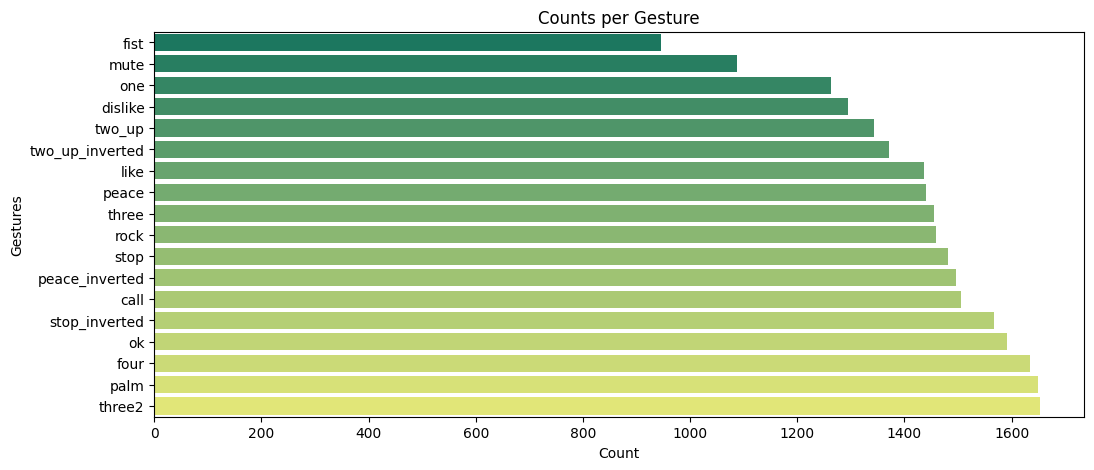

In [18]:
label_counts = hand_landmarks_df["label"].value_counts(ascending=True)   #.sort_values()

plt.figure(figsize=(12, 5))
sns.barplot(y=label_counts.index, x=label_counts.values, palette="summer",hue=label_counts.index)  # Swap x and y

plt.ylabel("Gestures")
plt.xlabel("Count")
plt.title("Counts per Gesture")

plt.show()

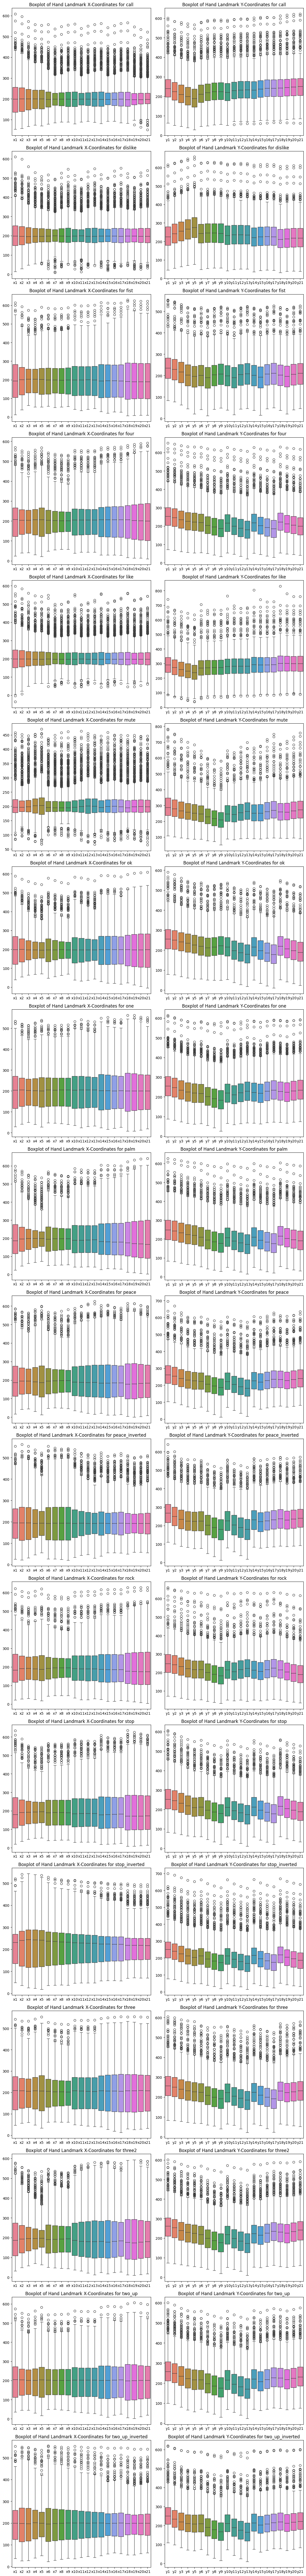

In [19]:
boxplots(hand_landmarks_df,gestures)

In [20]:
samples = hand_landmarks_df.sample(30,axis=0)

In [21]:
samples.head()

,x1,y1,z1,x2,y2,z2,x3,y3,z3,x4,...,x19,y19,z19,x20,y20,z20,x21,y21,z21,label
1205,137.604446,271.128235,-4.494480e-07,146.120831,251.863419,0.000155,159.918675,235.027969,-0.005247,171.189331,...,196.825516,283.788574,-0.032431,206.884369,287.749023,-0.028309,215.626328,290.227264,-0.024843,call
12761,96.598686,339.084808,4.348010e-07,110.849339,328.986984,-0.022906,119.119949,308.978894,-0.029571,112.152340,...,91.425499,294.458374,-0.044930,94.686275,305.923671,-0.041644,93.120495,314.406446,-0.031266,peace
11665,241.080574,271.217499,8.182640e-08,232.663765,266.931488,-0.005473,226.021591,260.182251,-0.008158,220.358070,...,251.132812,246.376816,-0.017198,253.599724,243.204727,-0.019430,255.734848,240.393692,-0.020847,palm
9728,280.211838,257.020111,-1.180240e-07,270.023827,250.116562,-0.017011,264.502418,238.801041,-0.028141,270.391113,...,297.838394,228.481567,-0.043640,292.598122,236.189911,-0.038136,289.097282,238.700623,-0.030747,one
10276,87.964457,266.676605,2.068860e-09,103.327080,253.846893,-0.016826,111.223972,233.734726,-0.027803,108.411736,...,75.341114,224.305862,-0.066855,82.354351,236.471039,-0.057497,79.163275,241.351181,-0.045794,one


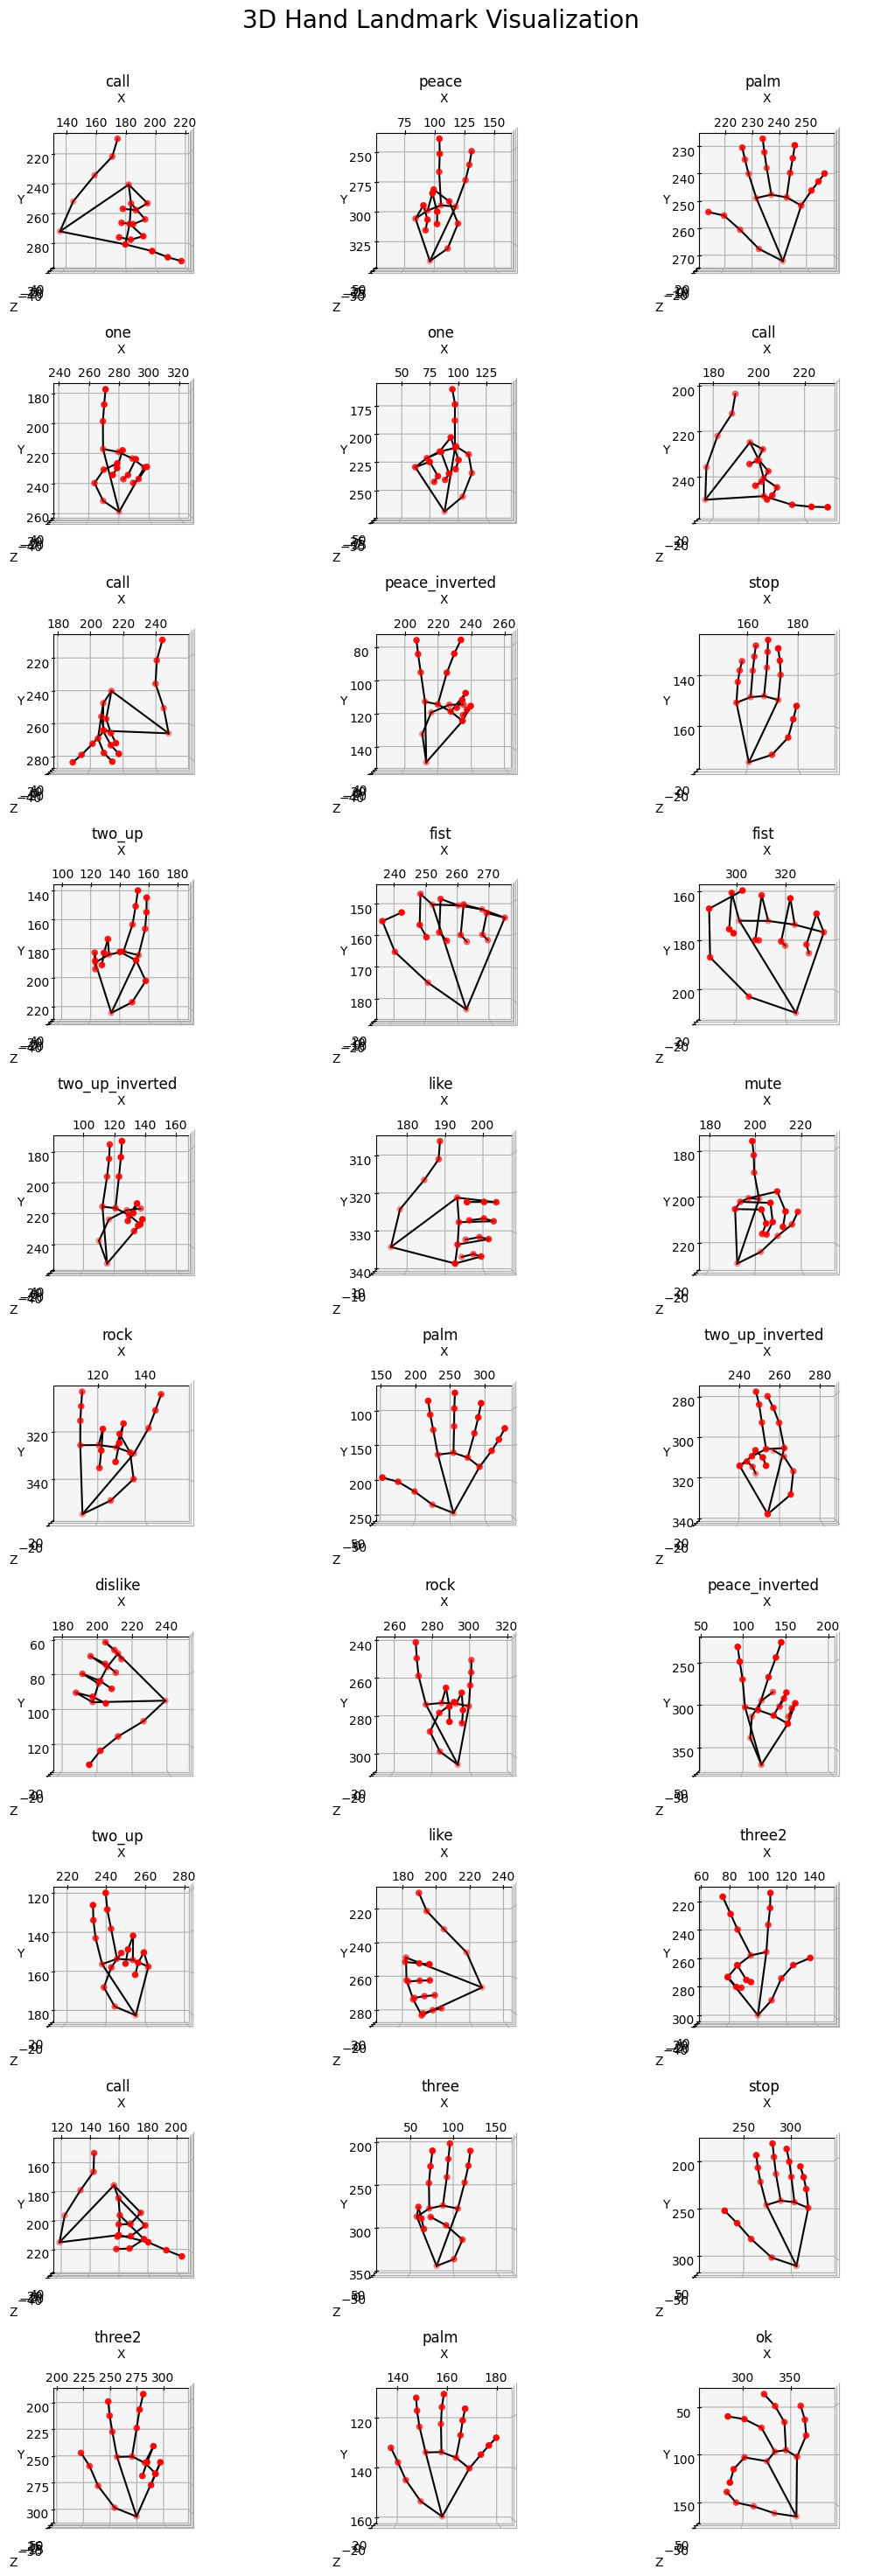

In [22]:
plot_samples(samples)

## Data Preparation

In [23]:
hand_landmarks_df.head()

,x1,y1,z1,x2,y2,z2,x3,y3,z3,x4,...,x19,y19,z19,x20,y20,z20,x21,y21,z21,label
0,262.669968,257.304901,-3.649200e-07,257.417542,247.109055,0.004224,246.882958,241.716827,0.005798,236.384537,...,223.345093,255.490692,-0.020450,215.043365,258.114746,-0.024577,208.006393,259.608673,-0.026722,call
1,83.351778,346.059113,-2.345270e-07,81.925037,328.562347,-0.011102,90.080132,311.535248,-0.021096,95.641823,...,132.451618,341.794434,-0.038175,142.773583,342.829254,-0.037336,152.431698,343.015991,-0.036136,call
2,187.756977,260.235492,-2.417310e-07,195.460579,241.506035,-0.000184,207.259529,223.674339,-0.009687,215.413628,...,250.301010,268.602938,-0.044068,262.425133,271.276638,-0.040469,272.989952,272.272231,-0.038301,call
3,114.976696,331.594238,-1.233260e-07,114.503494,320.549957,-0.002824,116.636627,310.080994,-0.008911,117.685066,...,145.195450,329.357544,-0.027622,151.053200,329.712341,-0.027863,155.990364,329.548828,-0.027723,call
4,188.795288,141.727867,-1.623000e-07,188.520905,127.947464,-0.002884,191.982880,111.010563,-0.008115,192.552521,...,226.696396,132.263248,-0.025113,234.831741,130.684147,-0.024087,241.587769,128.477188,-0.023486,call


In [24]:
new_hand_landmarks_df=hand_landmarks_df.copy()

In [25]:
# This step turns the wrist into the point of origin
new_hand_landmarks_df.iloc[:,0:-1:3]=new_hand_landmarks_df.iloc[:,0:-1:3].sub(new_hand_landmarks_df['x1'],axis=0)
new_hand_landmarks_df.iloc[:,1:-1:3]=new_hand_landmarks_df.iloc[:,1:-1:3].sub(new_hand_landmarks_df['y1'],axis=0)

In [26]:
new_hand_landmarks_df.head()

,x1,y1,z1,x2,y2,z2,x3,y3,z3,x4,...,x19,y19,z19,x20,y20,z20,x21,y21,z21,label
0,0.0,0.0,-3.649200e-07,-5.252426,-10.195846,0.004224,-15.787010,-15.588074,0.005798,-26.285431,...,-39.324875,-1.814209,-0.020450,-47.626602,0.809845,-0.024577,-54.663574,2.303772,-0.026722,call
1,0.0,0.0,-2.345270e-07,-1.426741,-17.496765,-0.011102,6.728353,-34.523865,-0.021096,12.290045,...,49.099840,-4.264679,-0.038175,59.421804,-3.229858,-0.037336,69.079920,-3.043121,-0.036136,call
2,0.0,0.0,-2.417310e-07,7.703602,-18.729457,-0.000184,19.502552,-36.561153,-0.009687,27.656651,...,62.544033,8.367446,-0.044068,74.668156,11.041146,-0.040469,85.232975,12.036739,-0.038301,call
3,0.0,0.0,-1.233260e-07,-0.473202,-11.044281,-0.002824,1.659931,-21.513245,-0.008911,2.708370,...,30.218754,-2.236694,-0.027622,36.076504,-1.881897,-0.027863,41.013668,-2.045410,-0.027723,call
4,0.0,0.0,-1.623000e-07,-0.274384,-13.780403,-0.002884,3.187591,-30.717304,-0.008115,3.757233,...,37.901108,-9.464619,-0.025113,46.036453,-11.043720,-0.024087,52.792481,-13.250679,-0.023486,call


In [27]:
# Normalized using Euclidean distance from the wrist to base of middle finger
# This approach is more consistent than the tip of the middle finger (better model performance for similar hyperparameters)

normalized_hand_landmarks_df = new_hand_landmarks_df.copy()
wrist_x = normalized_hand_landmarks_df['x1'].values
wrist_y = normalized_hand_landmarks_df['y1'].values
# wrist_z = normalized_hand_landmarks_df['z1'].values

fingertip_x = normalized_hand_landmarks_df['x10'].values
fingertip_y = normalized_hand_landmarks_df['y10'].values
# fingertip_z = normalized_hand_landmarks_df['z10'].values

scale_factor = np.sqrt((fingertip_x - wrist_x)**2 + (fingertip_y - wrist_y)**2).reshape(-1, 1)
normalized_hand_landmarks_df.iloc[:, :-1:3] /= scale_factor  # Normalize x
normalized_hand_landmarks_df.iloc[:, 1::3] /= scale_factor  # Normalize y

In [28]:
normalized_hand_landmarks_df

,x1,y1,z1,x2,y2,z2,x3,y3,z3,x4,...,x19,y19,z19,x20,y20,z20,x21,y21,z21,label
0,0.0,0.0,-3.649200e-07,-0.163212,-0.316822,0.004224,-0.490560,-0.484379,0.005798,-0.816785,...,-1.221968,-0.056374,-0.020450,-1.479933,0.025165,-0.024577,-1.698597,0.071587,-0.026722,call
1,0.0,0.0,-2.345270e-07,-0.035390,-0.434008,-0.011102,0.166897,-0.856365,-0.021096,0.304855,...,1.217923,-0.105785,-0.038175,1.473959,-0.080117,-0.037336,1.713529,-0.075485,-0.036136,call
2,0.0,0.0,-2.417310e-07,0.161546,-0.392759,-0.000184,0.408971,-0.766692,-0.009687,0.579964,...,1.311557,0.175466,-0.044068,1.565801,0.231534,-0.040469,1.787347,0.252412,-0.038301,call
3,0.0,0.0,-1.233260e-07,-0.019358,-0.451797,-0.002824,0.067904,-0.880059,-0.008911,0.110793,...,1.236182,-0.091498,-0.027622,1.475810,-0.076984,-0.027863,1.677779,-0.083673,-0.027723,call
4,0.0,0.0,-1.623000e-07,-0.009460,-0.475088,-0.002884,0.109894,-1.058998,-0.008115,0.129533,...,1.306664,-0.326298,-0.025113,1.587135,-0.380739,-0.024087,1.820053,-0.456825,-0.023486,call
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25670,0.0,0.0,4.323660e-07,0.245834,-0.415296,0.007132,0.209913,-0.822088,0.004480,-0.037013,...,-0.576094,-0.970666,-0.028861,-0.495638,-0.873650,-0.016911,-0.442383,-0.752627,-0.006697,two_up_inverted
25671,0.0,0.0,3.808550e-07,-0.281623,-0.405000,0.003778,-0.251685,-0.788039,-0.001519,-0.015223,...,0.587626,-0.998558,-0.043690,0.499127,-0.902732,-0.029510,0.443878,-0.768913,-0.015630,two_up_inverted
25672,0.0,0.0,5.912490e-07,0.300052,-0.315438,0.001354,0.317932,-0.684872,-0.001674,0.170707,...,-0.408848,-0.809867,-0.031740,-0.350143,-0.701625,-0.021970,-0.307853,-0.597995,-0.010803,two_up_inverted
25673,0.0,0.0,4.319560e-07,-0.165072,-0.397555,0.006174,-0.055164,-0.775678,0.001893,0.209648,...,0.809827,-0.832038,-0.046297,0.757541,-0.698939,-0.032800,0.657510,-0.597044,-0.020277,two_up_inverted


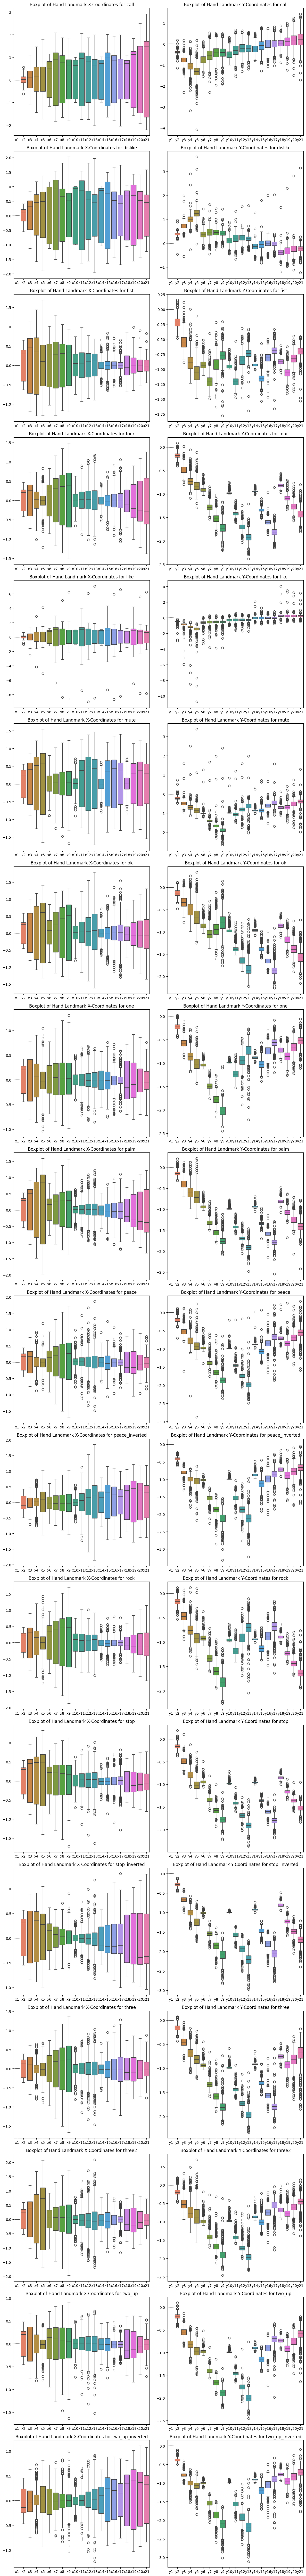

In [29]:
boxplots(normalized_hand_landmarks_df,gestures)

In [30]:
normalized_samples = normalized_hand_landmarks_df.sample(6,axis=0)

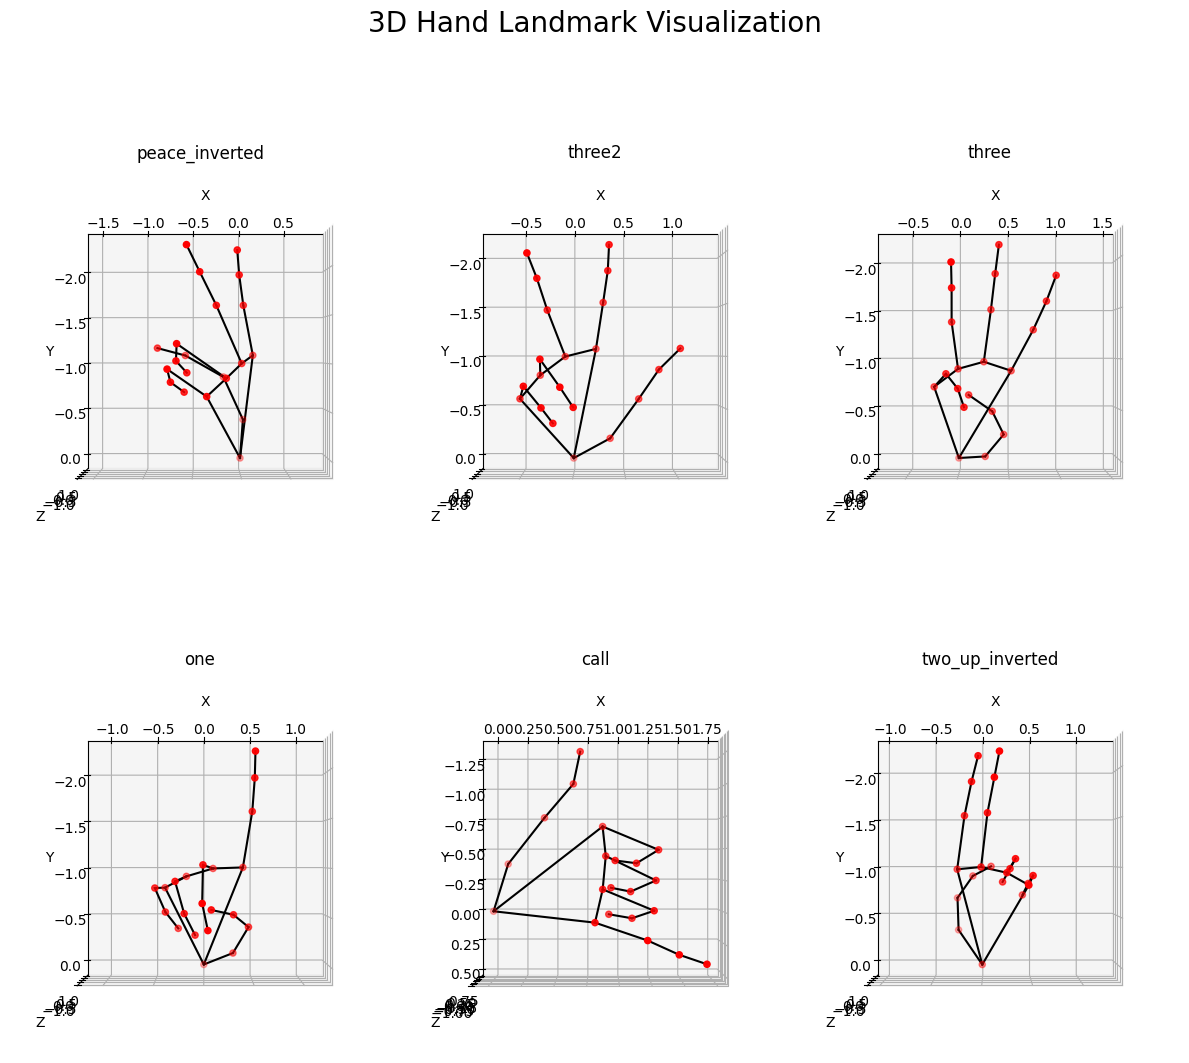

In [31]:
plot_samples(normalized_samples,12)



In [32]:
# label mapping is used to encode labels into integers
label_mapping = {label: idx for idx, label in enumerate(normalized_hand_landmarks_df["label"].unique())}

# inverse mapping is used to decode labels from integers to words
inverse_mapping = {v: k for k, v in label_mapping.items()}


label_mapping, inverse_mapping

({'call': 0,
  'dislike': 1,
  'fist': 2,
  'four': 3,
  'like': 4,
  'mute': 5,
  'ok': 6,
  'one': 7,
  'palm': 8,
  'peace': 9,
  'peace_inverted': 10,
  'rock': 11,
  'stop': 12,
  'stop_inverted': 13,
  'three': 14,
  'three2': 15,
  'two_up': 16,
  'two_up_inverted': 17},
 {0: 'call',
  1: 'dislike',
  2: 'fist',
  3: 'four',
  4: 'like',
  5: 'mute',
  6: 'ok',
  7: 'one',
  8: 'palm',
  9: 'peace',
  10: 'peace_inverted',
  11: 'rock',
  12: 'stop',
  13: 'stop_inverted',
  14: 'three',
  15: 'three2',
  16: 'two_up',
  17: 'two_up_inverted'})

In [33]:
normalized_hand_landmarks_df["label"] = normalized_hand_landmarks_df["label"].map(label_mapping)
normalized_hand_landmarks_df.head()

,x1,y1,z1,x2,y2,z2,x3,y3,z3,x4,...,x19,y19,z19,x20,y20,z20,x21,y21,z21,label
0,0.0,0.0,-3.649200e-07,-0.163212,-0.316822,0.004224,-0.490560,-0.484379,0.005798,-0.816785,...,-1.221968,-0.056374,-0.020450,-1.479933,0.025165,-0.024577,-1.698597,0.071587,-0.026722,0
1,0.0,0.0,-2.345270e-07,-0.035390,-0.434008,-0.011102,0.166897,-0.856365,-0.021096,0.304855,...,1.217923,-0.105785,-0.038175,1.473959,-0.080117,-0.037336,1.713529,-0.075485,-0.036136,0
2,0.0,0.0,-2.417310e-07,0.161546,-0.392759,-0.000184,0.408971,-0.766692,-0.009687,0.579964,...,1.311557,0.175466,-0.044068,1.565801,0.231534,-0.040469,1.787347,0.252412,-0.038301,0
3,0.0,0.0,-1.233260e-07,-0.019358,-0.451797,-0.002824,0.067904,-0.880059,-0.008911,0.110793,...,1.236182,-0.091498,-0.027622,1.475810,-0.076984,-0.027863,1.677779,-0.083673,-0.027723,0
4,0.0,0.0,-1.623000e-07,-0.009460,-0.475088,-0.002884,0.109894,-1.058998,-0.008115,0.129533,...,1.306664,-0.326298,-0.025113,1.587135,-0.380739,-0.024087,1.820053,-0.456825,-0.023486,0


## Splitting Data

In [34]:
features =normalized_hand_landmarks_df.drop(['label'], axis=1)
labels = normalized_hand_landmarks_df['label']

In [35]:
features_train, features_test, labels_train, labels_test =train_test_split(features, labels,test_size=0.25,random_state=29)

In [36]:
print(len(features_train))
print(len(features_test))
print(len(labels_train))
print(len(labels_test))

19256
6419
19256
6419


## Training/Testing Models

### Decision Tree

Accuracy (Train set):  1.0
Accuracy:  0.9510827231656022
F1-score:  0.9511647081678765
recall_score:  0.9510827231656022
precision_score:  0.9514639705021473


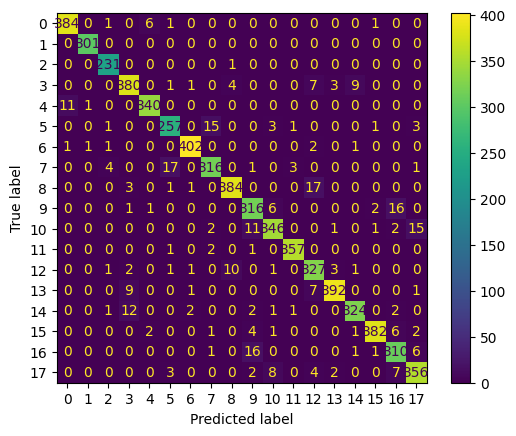

2025/06/02 01:27:57 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


In [74]:
from sklearn.tree import DecisionTreeClassifier
with mlflow.start_run(run_name="Decision Tree"):

    dt_model =DecisionTreeClassifier()
    dt_model.fit(features_train,labels_train)
    
    model_scores(features_train, features_test, labels_train, labels_test, dt_model)

    mlflow.log_param("model_type", "DecisionTree")
    mlflow.log_params(dt_model.get_params())

    predicted_labels = dt_model.predict(features_test)
    mlflow.log_metric("accuracy_train", dt_model.score(features_train, labels_train))
    mlflow.log_metric("accuracy_test", dt_model.score(features_test, labels_test))
    mlflow.log_metric("f1_score", f1_score(labels_test, predicted_labels, average='weighted'))
    mlflow.log_metric("recall", recall_score(labels_test, predicted_labels, average='weighted'))
    mlflow.log_metric("precision", precision_score(labels_test, predicted_labels, average='weighted'))

    mlflow.sklearn.log_model(dt_model, "decision_tree_model")    


### SVM

Accuracy (Train set):  0.9750207727461571
Accuracy:  0.9707119489016981
F1-score:  0.9708089113125485
recall_score:  0.9707119489016981
precision_score:  0.9715686151580222


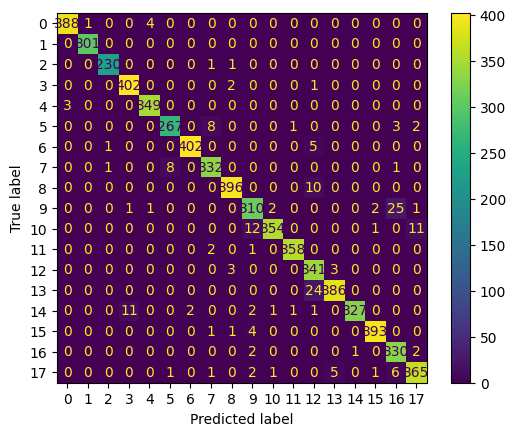

2025/06/02 01:28:48 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


In [75]:
from sklearn.svm import SVC

with mlflow.start_run(run_name="SVM"):
    svm_model = SVC()
    svm_model.fit(features_train, labels_train)
    model_scores(features_train, features_test, labels_train, labels_test, svm_model)

    mlflow.log_param("model_type", "SVM")
    mlflow.log_params(svm_model.get_params())

    predicted_labels = svm_model.predict(features_test)
    mlflow.log_metric("accuracy_train", svm_model.score(features_train, labels_train))
    mlflow.log_metric("accuracy_test", svm_model.score(features_test, labels_test))
    mlflow.log_metric("f1_score", f1_score(labels_test, predicted_labels, average='weighted'))
    mlflow.log_metric("recall", recall_score(labels_test, predicted_labels, average='weighted'))
    mlflow.log_metric("precision", precision_score(labels_test, predicted_labels, average='weighted'))

    mlflow.sklearn.log_model(svm_model, "svm_model")


### Random Forest

Accuracy (Train set):  1.0
Accuracy:  0.9750739990652749
F1-score:  0.9751048981041867
recall_score:  0.9750739990652749
precision_score:  0.9753091028572288


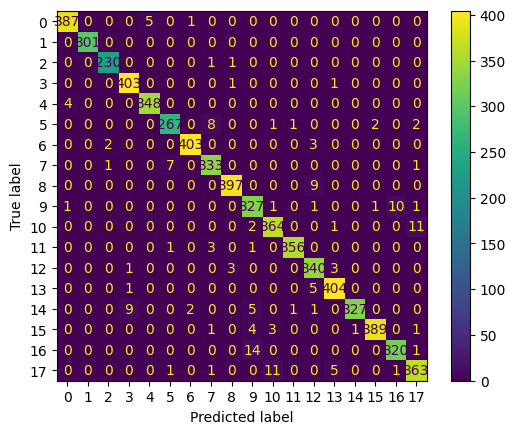

2025/06/02 01:29:12 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


In [76]:
from sklearn.ensemble import RandomForestClassifier

with mlflow.start_run(run_name="Random Forest"):
    rf_model = RandomForestClassifier()
    rf_model.fit(features_train, labels_train)
    model_scores(features_train, features_test, labels_train, labels_test, rf_model)

    mlflow.log_param("model_type", "RandomForest")
    mlflow.log_params(rf_model.get_params())

    predicted_labels = rf_model.predict(features_test)
    mlflow.log_metric("accuracy_train", rf_model.score(features_train, labels_train))
    mlflow.log_metric("accuracy_test", rf_model.score(features_test, labels_test))
    mlflow.log_metric("f1_score", f1_score(labels_test, predicted_labels, average='weighted'))
    mlflow.log_metric("recall", recall_score(labels_test, predicted_labels, average='weighted'))
    mlflow.log_metric("precision", precision_score(labels_test, predicted_labels, average='weighted'))

    mlflow.sklearn.log_model(rf_model, "random_forest_model")


### KNN

Accuracy (Train set):  0.9833818030743664
Accuracy:  0.98005919925222
F1-score:  0.9800947824032548
recall_score:  0.98005919925222
precision_score:  0.9804479885733624


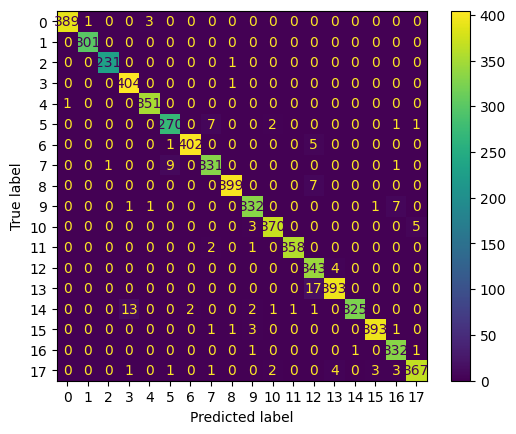

2025/06/02 01:29:21 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


In [77]:
from sklearn.neighbors import KNeighborsClassifier

with mlflow.start_run(run_name="KNN"):
    KNN_model = KNeighborsClassifier()
    KNN_model.fit(features_train, labels_train)
    model_scores(features_train, features_test, labels_train, labels_test, KNN_model)

    mlflow.log_param("model_type", "KNN")
    mlflow.log_params(KNN_model.get_params())

    predicted_labels = KNN_model.predict(features_test)
    mlflow.log_metric("accuracy_train", KNN_model.score(features_train, labels_train))
    mlflow.log_metric("accuracy_test", KNN_model.score(features_test, labels_test))
    mlflow.log_metric("f1_score", f1_score(labels_test, predicted_labels, average='weighted'))
    mlflow.log_metric("recall", recall_score(labels_test, predicted_labels, average='weighted'))
    mlflow.log_metric("precision", precision_score(labels_test, predicted_labels, average='weighted'))

    mlflow.sklearn.log_model(KNN_model, "knn_untuned_model")


### XGBoost

Accuracy (Train set):  1.0
Accuracy:  0.9811497117931142
F1-score:  0.9811576701314371
recall_score:  0.9811497117931142
precision_score:  0.981277081336662


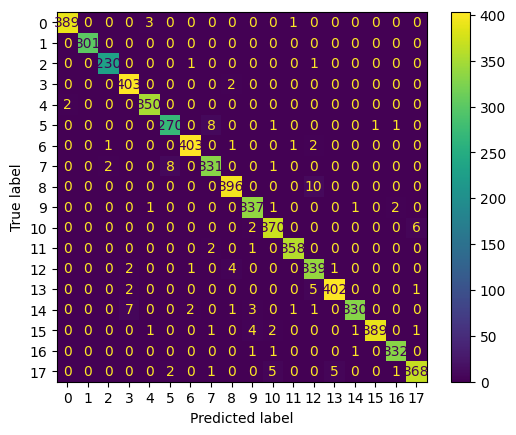

2025/06/02 01:29:33 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


In [78]:
from xgboost import XGBClassifier

with mlflow.start_run(run_name="XGBoost"):
    xgboost_model = XGBClassifier()
    xgboost_model.fit(features_train, labels_train)
    model_scores(features_train, features_test, labels_train, labels_test, xgboost_model)

    mlflow.log_param("model_type", "XGBoost")
    mlflow.log_params(xgboost_model.get_params())

    predicted_labels = xgboost_model.predict(features_test)
    mlflow.log_metric("accuracy_train", xgboost_model.score(features_train, labels_train))
    mlflow.log_metric("accuracy_test", xgboost_model.score(features_test, labels_test))
    mlflow.log_metric("f1_score", f1_score(labels_test, predicted_labels, average='weighted'))
    mlflow.log_metric("recall", recall_score(labels_test, predicted_labels, average='weighted'))
    mlflow.log_metric("precision", precision_score(labels_test, predicted_labels, average='weighted'))

    mlflow.sklearn.log_model(xgboost_model, "xgboost_untuned_model")


**Without any hyperparameter tuning, each model performed on test set as following:**
* Desicion Tree -->  95.13% Accuracy
* SVM -->  97.07% Accuracy
* Random Forest -->  97.46% Accuracy
* KNN -->  98.01% Accuracy
* XGBoost -->  98.11% Accuracy


## Hyperparameters Tuning

### XGBoost

In [79]:
param_dist = {
    "learning_rate": [0.1, 0.2],
    "max_depth": [3, 6],
    "n_estimators": [300, 500],
    "subsample": [0.6, 1.0]
}

xgboost = XGBClassifier()
xgboost_cv = RandomizedSearchCV(estimator=xgboost, param_distributions=param_dist, n_iter=10,
                                    scoring='accuracy', cv=3, verbose=3, random_state=29,n_jobs=1)


Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV 1/3] END learning_rate=0.1, max_depth=6, n_estimators=300, subsample=0.6;, score=0.981 total time=  13.5s
[CV 2/3] END learning_rate=0.1, max_depth=6, n_estimators=300, subsample=0.6;, score=0.981 total time=  14.3s
[CV 3/3] END learning_rate=0.1, max_depth=6, n_estimators=300, subsample=0.6;, score=0.981 total time=  16.3s
[CV 1/3] END learning_rate=0.1, max_depth=6, n_estimators=500, subsample=1.0;, score=0.981 total time=  45.7s
[CV 2/3] END learning_rate=0.1, max_depth=6, n_estimators=500, subsample=1.0;, score=0.982 total time= 1.0min
[CV 3/3] END learning_rate=0.1, max_depth=6, n_estimators=500, subsample=1.0;, score=0.980 total time=  19.6s
[CV 1/3] END learning_rate=0.1, max_depth=6, n_estimators=500, subsample=0.6;, score=0.980 total time=  20.2s
[CV 2/3] END learning_rate=0.1, max_depth=6, n_estimators=500, subsample=0.6;, score=0.980 total time=  21.1s
[CV 3/3] END learning_rate=0.1, max_depth=6, n_estimators=5

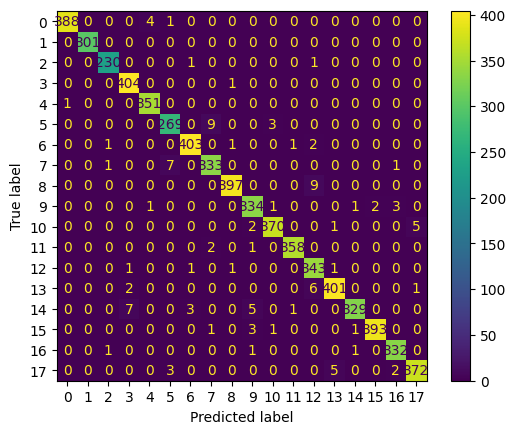

2025/06/02 01:38:41 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


In [80]:
with mlflow.start_run(run_name="XGBoost Tuned"):
    xgboost_cv.fit(features_train, labels_train)
    best_xgboost_model = xgboost_cv.best_estimator_

    model_scores(features_train, features_test, labels_train, labels_test, best_xgboost_model)

    mlflow.log_param("model_type", "XGBoost_Tuned")
    mlflow.log_params(best_xgboost_model.get_params())

    predicted_labels = best_xgboost_model.predict(features_test)
    mlflow.log_metric("accuracy_train", best_xgboost_model.score(features_train, labels_train))
    mlflow.log_metric("accuracy_test", best_xgboost_model.score(features_test, labels_test))
    mlflow.log_metric("f1_score", f1_score(labels_test, predicted_labels, average='weighted'))
    mlflow.log_metric("recall", recall_score(labels_test, predicted_labels, average='weighted'))
    mlflow.log_metric("precision", precision_score(labels_test, predicted_labels, average='weighted'))

    mlflow.sklearn.log_model(best_xgboost_model, "xgboost_tuned_model")

    joblib.dump(best_xgboost_model, "models/optim_xgboost_model.pkl")
    mlflow.log_artifact("models/optim_xgboost_model.pkl")

### KNN

In [81]:
param_grid = {
    'n_neighbors': [5, 7, 9, 11, 13],  
    'metric': ['euclidean', 'manhattan', 'minkowski']  
}
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=29)
knn=KNeighborsClassifier()
knn_cv=GridSearchCV(knn, param_grid, cv=skf, scoring='accuracy', n_jobs=-1, verbose=3)

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Accuracy (Train set):  0.9833818030743664
Accuracy:  0.98005919925222
F1-score:  0.9800947824032548
recall_score:  0.98005919925222
precision_score:  0.9804479885733624


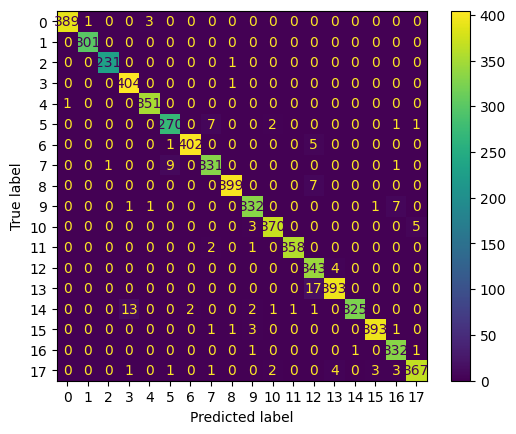

2025/06/02 01:39:03 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


In [82]:
with mlflow.start_run(run_name="KNN Tuned"):
    knn_cv.fit(features_train, labels_train)
    best_KNN_model = knn_cv.best_estimator_

    model_scores(features_train, features_test, labels_train, labels_test, best_KNN_model)

    mlflow.log_param("model_type", "KNN_Tuned")
    mlflow.log_params(best_KNN_model.get_params())

    predicted_labels = best_KNN_model.predict(features_test)
    mlflow.log_metric("accuracy_train", best_KNN_model.score(features_train, labels_train))
    mlflow.log_metric("accuracy_test", best_KNN_model.score(features_test, labels_test))
    mlflow.log_metric("f1_score", f1_score(labels_test, predicted_labels, average='weighted'))
    mlflow.log_metric("recall", recall_score(labels_test, predicted_labels, average='weighted'))
    mlflow.log_metric("precision", precision_score(labels_test, predicted_labels, average='weighted'))

    mlflow.sklearn.log_model(best_KNN_model, "knn_tuned_model")

    joblib.dump(best_KNN_model, "models/optim_KNN_model.pkl")
    mlflow.log_artifact("models/optim_KNN_model.pkl")

### Conclusion
**After hyperparameter tuning, the best performing model was XGBoost:**
* Hyperparameters: {'subsample': 0.6, 'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.2}
* Accuracy: 98.27%

**KNN performed best with default parameter. An accuracy of 98.01% was quite impressive for model of such simplicity**


## Processing Recorded Video

In [37]:
import cv2
import mediapipe as mp

In [38]:
model = joblib.load("models/optim_xgboost_model.pkl")

In [39]:
def predict_gesture(landmarks):
    return model.predict(landmarks)[0]

In [40]:
def normalize_landmarks(landmarks):

    df = pd.DataFrame([landmarks], columns=[f"{axis}{i}" for i in range(1, 22) for axis in ['x', 'y', 'z']])
    df.iloc[:,0:-1:3]=df.iloc[:,0:-1:3].sub(df['x1'],axis=0)
    df.iloc[:,1:-1:3]=df.iloc[:,1:-1:3].sub(df['y1'],axis=0)
    
    wrist_x = df['x1'].values
    wrist_y = df['y1'].values
    # wrist_z = normalized_hand_landmarks_df['z1'].values

    fingertip_x = df['x10'].values
    fingertip_y = df['y10'].values
    # fingertip_z = normalized_hand_landmarks_df['z10'].values

    scale_factor = np.sqrt((fingertip_x - wrist_x)**2 + (fingertip_y - wrist_y)**2).reshape(-1, 1)
    df.iloc[:, :-1:3] /= scale_factor  # Normalize x
    df.iloc[:, 1::3] /= scale_factor  # Normalize y
    
    return df

In [41]:
mp_hands = mp.solutions.hands
mp_drawing = mp.solutions.drawing_utils
hands = mp_hands.Hands(static_image_mode=False, max_num_hands=1, min_detection_confidence=0.5)

In [42]:
video_path = "videos/input1.mp4"  
cap = cv2.VideoCapture(video_path)

In [43]:
frame_width = int(cap.get(3))
frame_height = int(cap.get(4))
fps = int(cap.get(cv2.CAP_PROP_FPS))

In [44]:
output_path = "videos/output1.mp4" 
out = cv2.VideoWriter(output_path, cv2.VideoWriter_fourcc(*'mp4v'), fps, (frame_width, frame_height))


In [45]:

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # Convert frame to RGB (MediaPipe requirement)
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = hands.process(frame_rgb)
    if results.multi_hand_landmarks:
        for hand_landmarks in results.multi_hand_landmarks:
            mp_drawing.draw_landmarks(frame, hand_landmarks, mp_hands.HAND_CONNECTIONS)

            # Extract landmarks
            landmarks = []
            for lm in hand_landmarks.landmark:
                landmarks.extend([lm.x, lm.y, lm.z])
            normalized_landmarks = normalize_landmarks(landmarks)
            label_index = predict_gesture(normalized_landmarks)
            label_name = inverse_mapping.get(label_index, "Unknown")

            # Display label
            cv2.putText(frame, label_name, (100,100), cv2.FONT_HERSHEY_DUPLEX, 2.4, (0, 0, 0), 4)
            
    out.write(frame)
    # Exit on 'q' key
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break


In [46]:
cap.release()
out.release()
cv2.destroyAllWindows()
